<a href="https://colab.research.google.com/github/MBR4V0/Python/blob/main/Ajustes4_Parametros_XGBost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [580]:
from google.colab import drive


In [581]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [582]:
import os


In [583]:
"Aqui pode-se consultar as pastas que tem no arquivo DRIVE"
os.listdir('/content/drive/MyDrive')


['CNH-e (1).pdf',
 'CNH-e.pdf',
 'bl.351859139_40607751182_002003202402.03242024065419.temp.output.pdf',
 'Solicitação para Reforma.docx',
 'Solicitação para Reforma.gdoc',
 'Cópia de Solicitação para Reforma.docx',
 'Cópia de Cópia de Solicitação para Reforma.gdoc',
 'Cópia de Cópia de Solicitação para Reforma (1).docx',
 'Cópia de Cópia de Solicitação para Reforma.docx',
 'brModelo.jar',
 'Colab Notebooks',
 'autosave.chc',
 'Apresentação da empresa 3.pptx',
 'GITMAN, Principios Adm Financeira 2010.pdf',
 'ASSAF NETO, A. Finanças Corporativas e Valor.pdf',
 'ASSAF NETO Matematica-Financeira-e-Suas-Aplicacoes.pdf',
 'HAZZAN SAMUELfundamentos-da-matematica-elementar-e outros.pdf',
 'HOJI, M. Adm financeira e orçamentaria.pdf',
 'VASCONCELLOS e outros Manual-de-economia-e-negocios-internacionais.pdf',
 'Dados_Tratados',
 'Dados_teste']

In [584]:
os.listdir('/content/drive/MyDrive/Dados_teste')

['dados.xlsx']

**Etapa 9 — Instalar/importar o Pandas**

In [585]:
import pandas as pd

In [586]:
df = pd.read_excel(
    '/content/drive/MyDrive/Dados_teste/dados.xlsx'
)


In [682]:
display(df.head(10))

,Idade,Tumor_cm,Linfonodos,Ki67,TN,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,19,2.1,3,70,1,NaN,19,#NAME?
1,22,1.2,0,15,0,NaN,59,2.032862
2,28,3.4,5,80,1,NaN,25,3.671621
3,33,1.5,1,25,0,NaN,35,2.092436
4,34,2.8,4,65,1,NaN,59,2.762704
5,35,1.1,0,10,0,NaN,31,2.202933
6,49,2.9,3,75,1,NaN,67,1.584041
7,37,1.8,1,30,0,NaN,37,1.093247
8,68,4.2,6,85,1,NaN,39,2.167687
9,32,2.3,2,45,0,NaN,24,3.388807


E se você quiser trabalhar com um Excel que está no seu computador?

In [588]:
"from google.colab import files"

"arquivo = files.upload()"

'arquivo = files.upload()'

In [589]:
df.head()


,Idade,Tumor_cm,Linfonodos,Ki67,TN,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,19,2.1,3,70,1,NaN,19,#NAME?
1,22,1.2,0,15,0,NaN,59,2.032862
2,28,3.4,5,80,1,NaN,25,3.671621
3,33,1.5,1,25,0,NaN,35,2.092436
4,34,2.8,4,65,1,NaN,59,2.762704


In [644]:
df.shape


(1845, 8)

**Tratamento de Dados**

In [683]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())


Valores ausentes por coluna:
Idade            0
Tumor_cm         0
Linfonodos       0
Ki67             0
TN               0
Unnamed: 5    1845
Unnamed: 6       0
Unnamed: 7       0
dtype: int64


In [684]:
"distribuição do TN"
print("Distribuição da variável TN:")
print(df['TN'].value_counts())

print("\nProporção:")
print(df['TN'].value_counts(normalize=True))


Distribuição da variável TN:
TN
1    923
0    922
Name: count, dtype: int64

Proporção:
TN
1    0.500271
0    0.499729
Name: proportion, dtype: float64


In [685]:
"verificar se TN é realmente binário"
print("Valores existentes em TN:")
print(sorted(df['TN'].dropna().unique()))


Valores existentes em TN:
[np.int64(0), np.int64(1)]


In [694]:
"Remover duplicatas"
print("Número de registros antes:", len(df))

df_limpo = df.drop_duplicates().copy()

print("Número de registros depois:", len(df_limpo))
print("Duplicatas removidas:", len(df) - len(df_limpo))

Número de registros antes: 1845
Número de registros depois: 1845
Duplicatas removidas: 0


**Configuração X e Y**

In [695]:
X = df_limpo[
    ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']
].copy()

y = df_limpo['TN'].copy()

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

print("\nVariáveis utilizadas:")
print(X.columns.tolist())

print("\nVariável alvo:")
print(y.name)


Formato de X: (1845, 4)
Formato de y: (1845,)

Variáveis utilizadas:
['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']

Variável alvo:
TN


In [696]:
print("X:")
display(X)

print("y:")
display(y)

X:


,Idade,Tumor_cm,Linfonodos,Ki67
0,19,2.1,3,70
1,22,1.2,0,15
2,28,3.4,5,80
3,33,1.5,1,25
4,34,2.8,4,65
...,...,...,...,...
1840,55,3.6,6,82
1841,29,2.0,1,28
1842,39,3.8,8,88
1843,51,1.5,0,18


y:


,TN
0,1
1,0
2,1
3,0
4,1
...,...
1840,1
1841,0
1842,1
1843,0


In [697]:
"Teste 1 - Existe vazamento de dados (leakage) ?"
print("Variáveis usadas no modelo:")
print(X.columns.tolist())

print("\nVariável alvo:")
print(y.name)


Variáveis usadas no modelo:
['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']

Variável alvo:
TN


In [707]:
"Teste 2 - Correção de Duplicatas"
df_limpo = df.drop_duplicates().copy()

print("Antes:", len(df))
print("Depois:", len(df_limpo))
print("Removidas:", len(df) - len(df_limpo))

Antes: 1845
Depois: 1845
Removidas: 0


In [708]:
treino = X_treino.copy()
treino['TN'] = y_treino.values

teste = X_teste.copy()
teste['TN'] = y_teste.values


# ============================================================
# 2. Remover duplicatas dentro do conjunto de TREINO
# ============================================================

antes_treino = len(treino)

treino = treino.drop_duplicates().copy()

depois_treino = len(treino)

print("TREINO")
print("Antes:", antes_treino)
print("Depois:", depois_treino)
print("Duplicatas removidas:", antes_treino - depois_treino)


# ============================================================
# 3. Remover duplicatas dentro do conjunto de TESTE
# ============================================================

antes_teste = len(teste)

teste = teste.drop_duplicates().copy()

depois_teste = len(teste)

print("\nTESTE")
print("Antes:", antes_teste)
print("Depois:", depois_teste)
print("Duplicatas removidas:", antes_teste - depois_teste)


# ============================================================
# 4. Procurar registros que aparecem no TREINO e no TESTE
# ============================================================

duplicadas_treino_teste = pd.merge(
    treino,
    teste,
    how='inner'
)

print("\nREGISTROS PRESENTES NOS DOIS CONJUNTOS")
print("Quantidade:", len(duplicadas_treino_teste))

TREINO
Antes: 1476
Depois: 1381
Duplicatas removidas: 95

TESTE
Antes: 369
Depois: 364
Duplicatas removidas: 5

REGISTROS PRESENTES NOS DOIS CONJUNTOS
Quantidade: 47


In [709]:
"Teste 4"
print(
    df.groupby('TN')[['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']]
      .mean()
)

        Idade  Tumor_cm  Linfonodos       Ki67
TN                                            
0   43.662690  1.827657    0.516269  22.426247
1   43.946912  3.536186    5.780065  79.191766


**Separar treinamento e teste (70% dos dados para ensinar o modelo e 30% para testar.)**

In [710]:
"Recriando X e Y"
X = df_limpo[
    ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67']
]

y = df_limpo['TN']

In [711]:
" OPÇÃO 1 - Usando stratify=y"
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=45,
    stratify=y
)

print("Treinamento:", len(X_treino))
print("Teste:", len(X_teste))

Treinamento: 1476
Teste: 369


In [714]:
" OPÇÃO 2 - Usando Somente SPLIT ( Não rodar os dois )"
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=45
)

print("Treinamento:", len(X_treino))
print("Teste:", len(X_teste))

Treinamento: 1291
Teste: 554


Aqui sai o Treinamento que foi realizado ( Executar e conferir se foi a opção Utilizada)

In [715]:
print("Treinamento:", len(X_treino))
print("Teste:", len(X_teste))

Treinamento: 1291
Teste: 554


In [716]:
"Caracteristicas do Treino e do Teste"
treino_X = X_treino.copy()
teste_X = X_teste.copy()

duplicadas_X = pd.merge(
    treino_X,
    teste_X,
    on=['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67'],
    how='inner'
)

print(
    "Combinações de características presentes tanto no treino quanto no teste:",
    len(duplicadas_X)
)


Combinações de características presentes tanto no treino quanto no teste: 64


**Criar o XGBost**

In [717]:
!pip install -q xgboost

In [718]:
from xgboost import XGBClassifier


In [719]:
modelo_xgb = XGBClassifier(
    n_estimators=20,
    max_depth=2,
    learning_rate=0.5,
    random_state=45,
    eval_metric='logloss'
)

In [722]:
modelo_xgb.fit(
    X_treino,
    y_treino
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=20, n_jobs=None,
              num_parallel_tree=None, ...)

**Fazendo as previsões**

In [723]:
previsao_teste = modelo_xgb.predict(X_teste)

print("Previsões realizadas.")
print(previsao_teste[:20])

Previsões realizadas.
[0 1 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1]


In [724]:
probabilidade_teste = modelo_xgb.predict_proba(X_teste)[:, 1]

print(probabilidade_teste[:20])

[0.00143585 0.998485   0.998485   0.998485   0.998485   0.00143585
 0.00143585 0.00143585 0.998485   0.998485   0.00143585 0.00143585
 0.00143585 0.998485   0.00143585 0.00143585 0.998485   0.00143585
 0.998485   0.998485  ]


In [725]:
"Accuracy — TESTE"
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_teste,
    previsao_teste
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 1.0000
Accuracy: 100.00%


In [727]:
"TESTE"
from sklearn.metrics import precision_score

precision = precision_score(
    y_teste,
    previsao_teste,
    zero_division=0
)

print(f"Precision: {precision:.4f}")
print(f"Precision: {precision:.2%}")

Precision: 1.0000
Precision: 100.00%


In [728]:
"Recall / Sensitivity — TESTE"
from sklearn.metrics import recall_score

recall = recall_score(
    y_teste,
    previsao_teste,
    zero_division=0
)

print(f"Recall / Sensitivity: {recall:.4f}")
print(f"Recall / Sensitivity: {recall:.2%}")

Recall / Sensitivity: 1.0000
Recall / Sensitivity: 100.00%


In [729]:
"Specificity — TESTE"
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_teste,
    previsao_teste
)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Specificity: {specificity:.2%}")

Specificity: 1.0000
Specificity: 100.00%


In [730]:
"F1-score — TESTE"
from sklearn.metrics import f1_score

f1 = f1_score(
    y_teste,
    previsao_teste,
    zero_division=0
)

print(f"F1-score: {f1:.4f}")
print(f"F1-score: {f1:.2%}")


F1-score: 1.0000
F1-score: 100.00%


In [731]:
"ROC-AUC — TESTE"
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_teste,
    probabilidade_teste
)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.2%}")

ROC-AUC: 1.0000
ROC-AUC: 100.00%


Metricas - Tabela Geral:

In [733]:
print("=" * 45)
print("DESEMPENHO DO XGBOOST - CONJUNTO DE TESTE")
print("=" * 45)

print(f"Accuracy:             {accuracy:.2%}")
print(f"Precision:            {precision:.2%}")
print(f"Recall / Sensitivity: {recall:.2%}")
print(f"Specificity:          {specificity:.2%}")
print(f"F1-score:             {f1:.2%}")
print(f"ROC-AUC:              {roc_auc:.2%}")

print("=" * 45)


DESEMPENHO DO XGBOOST - CONJUNTO DE TESTE
Accuracy:             100.00%
Precision:            100.00%
Recall / Sensitivity: 100.00%
Specificity:          100.00%
F1-score:             100.00%
ROC-AUC:              100.00%


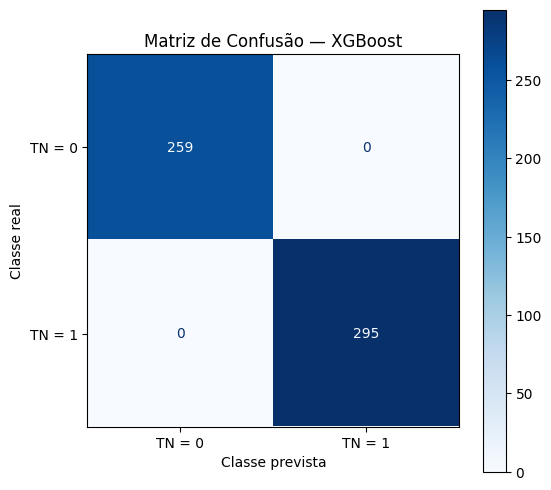

In [734]:
"Matriz de confusão"
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_teste,
    previsao_teste
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['TN = 0', 'TN = 1']
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap='Blues',
    ax=ax,
    values_format='d'
)

plt.title('Matriz de Confusão — XGBoost')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')

plt.show()

In [735]:
"Comparar desempenho no treino e no teste"
previsao_treino = modelo_xgb.predict(X_treino)

accuracy_treino = accuracy_score(
    y_treino,
    previsao_treino
)

accuracy_teste = accuracy_score(
    y_teste,
    previsao_teste
)

print(f"Accuracy no treinamento: {accuracy_treino:.2%}")
print(f"Accuracy no teste:       {accuracy_teste:.2%}")


Accuracy no treinamento: 100.00%
Accuracy no teste:       100.00%


In [736]:
"Classification Report"
from sklearn.metrics import classification_report

print(
    classification_report(
        y_teste,
        previsao_teste,
        target_names=['TN = 0', 'TN = 1'],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      TN = 0     1.0000    1.0000    1.0000       259
      TN = 1     1.0000    1.0000    1.0000       295

    accuracy                         1.0000       554
   macro avg     1.0000    1.0000    1.0000       554
weighted avg     1.0000    1.0000    1.0000       554



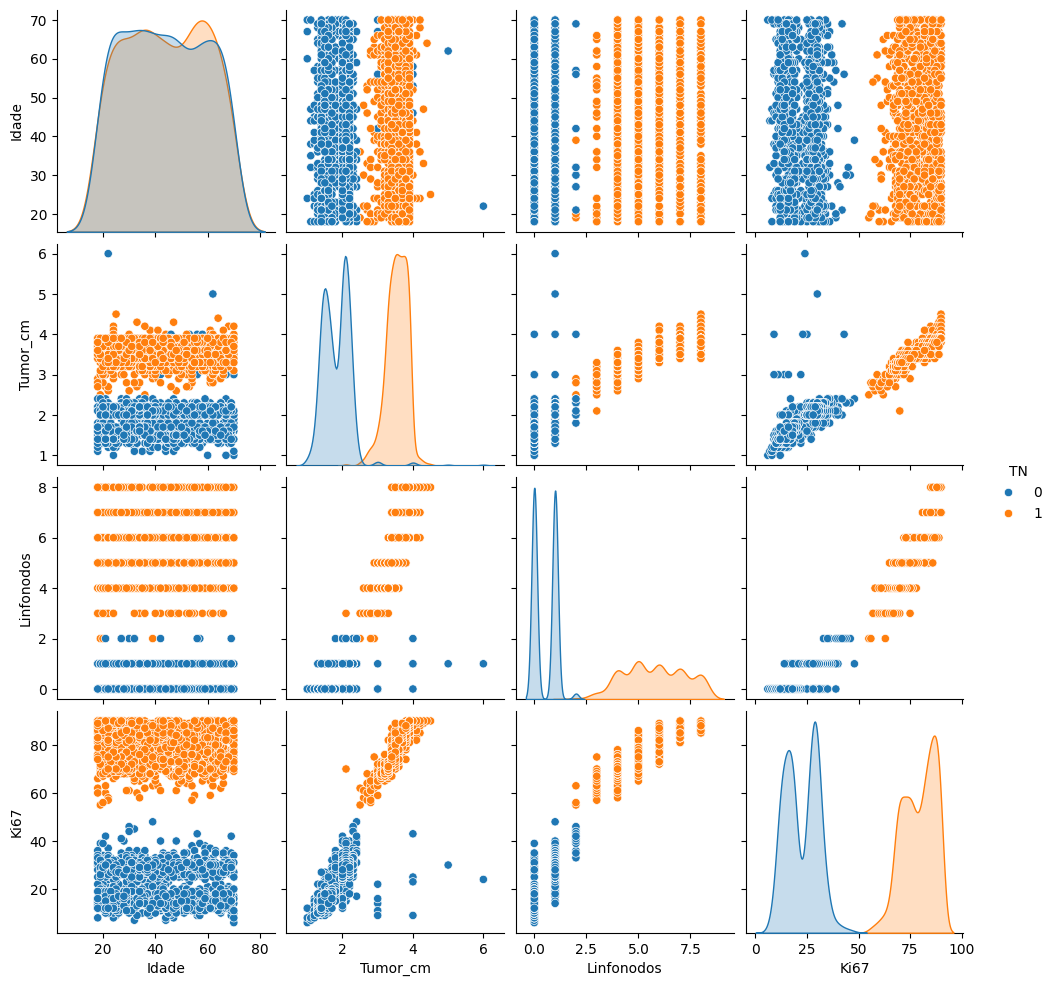

In [737]:
"Gráfico Geral"
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df_limpo[
        ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67', 'TN']
    ],
    hue='TN'
)

plt.show()

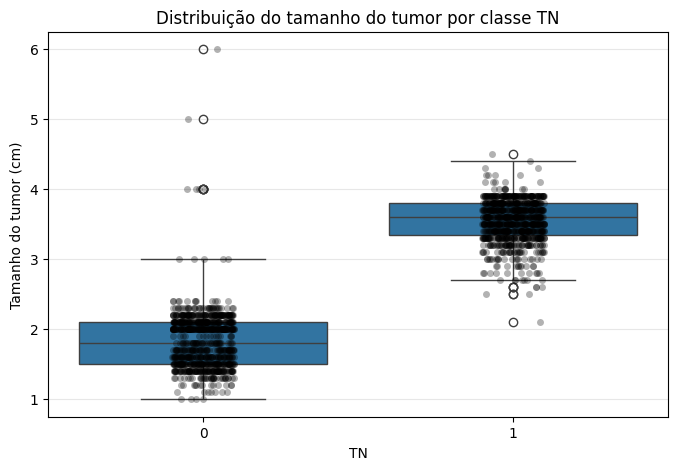

In [738]:
"Boxplot — Tumor"
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_limpo,
    x='TN',
    y='Tumor_cm'
)

sns.stripplot(
    data=df_limpo,
    x='TN',
    y='Tumor_cm',
    color='black',
    alpha=0.3
)

plt.xlabel('TN')
plt.ylabel('Tamanho do tumor (cm)')
plt.title('Distribuição do tamanho do tumor por classe TN')
plt.grid(axis='y', alpha=0.3)

plt.show()

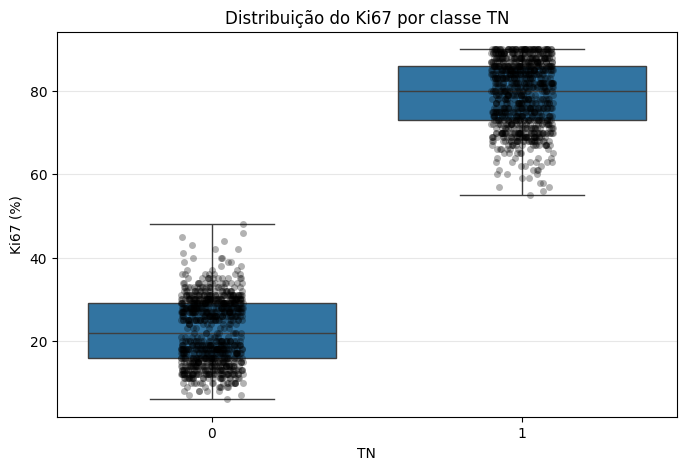

In [740]:
"Boxplot — Ki67"
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_limpo,
    x='TN',
    y='Ki67'
)

sns.stripplot(
    data=df_limpo,
    x='TN',
    y='Ki67',
    color='black',
    alpha=0.3
)

plt.xlabel('TN')
plt.ylabel('Ki67 (%)')
plt.title('Distribuição do Ki67 por classe TN')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [741]:
"Correlação"
correlacao = df_limpo[
    ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67', 'TN']
].corr()

display(correlacao)

,Idade,Tumor_cm,Linfonodos,Ki67,TN
Idade,1.000000,0.013412,0.004215,0.006517,0.009226
Tumor_cm,0.013412,1.000000,0.945326,0.969349,0.923878
Linfonodos,0.004215,0.945326,1.000000,0.974698,0.924934
Ki67,0.006517,0.969349,0.974698,1.000000,0.963917
TN,0.009226,0.923878,0.924934,0.963917,1.000000


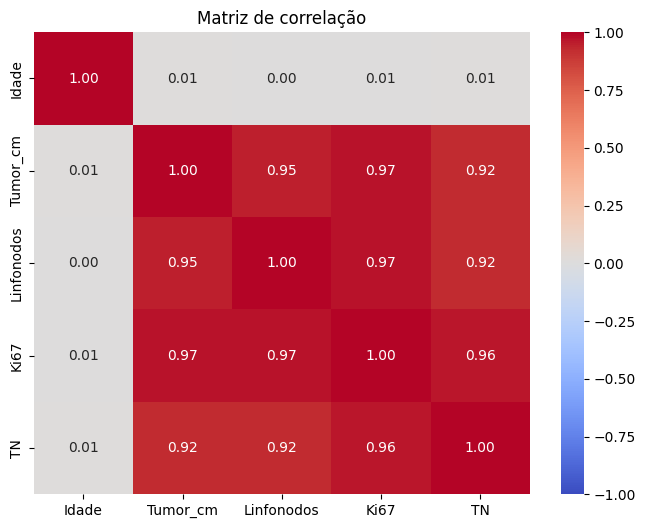

In [742]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Matriz de correlação')
plt.show()

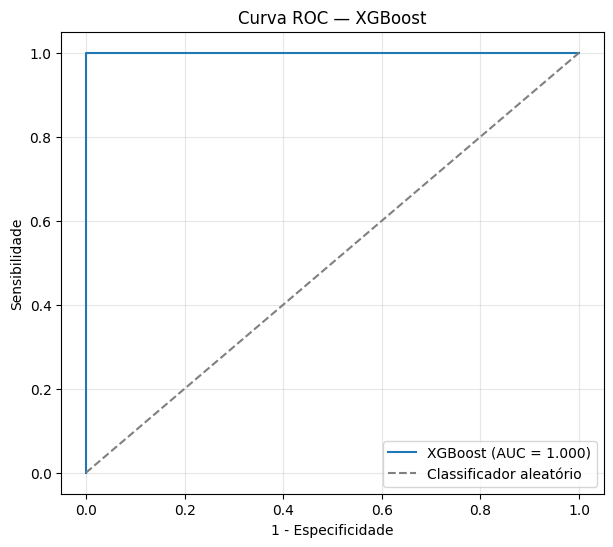

In [743]:
"ROC Curve"
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_teste,
    probabilidade_teste
)

auc = roc_auc_score(
    y_teste,
    probabilidade_teste
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC = {auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    label='Classificador aleatório'
)

plt.xlabel('1 - Especificidade')
plt.ylabel('Sensibilidade')
plt.title('Curva ROC — XGBoost')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [744]:
"Validação cruzada"
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=45
)

resultados_cv = cross_validate(
    modelo_xgb,
    X,
    y,
    cv=cv,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc'
    ]
)

print("RESULTADOS DA VALIDAÇÃO CRUZADA")
print("=" * 45)

for metrica in [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]:
    valores = resultados_cv[f'test_{metrica}']

    print(
        f"{metrica.upper():10s}: "
        f"{valores.mean():.4f} ± {valores.std():.4f}"
    )

RESULTADOS DA VALIDAÇÃO CRUZADA
ACCURACY  : 0.9989 ± 0.0022
PRECISION : 1.0000 ± 0.0000
RECALL    : 0.9978 ± 0.0043
F1        : 0.9989 ± 0.0022
ROC_AUC   : 0.9989 ± 0.0022


In [749]:
import pandas as pd

importancias = pd.Series(
    modelo_xgb.feature_importances_,
    index=X_treino.columns
).sort_values(ascending=False)

print("Importância das variáveis:")
display(importancias)


Importância das variáveis:


,0
Ki67,1.0
Idade,0.0
Tumor_cm,0.0
Linfonodos,0.0


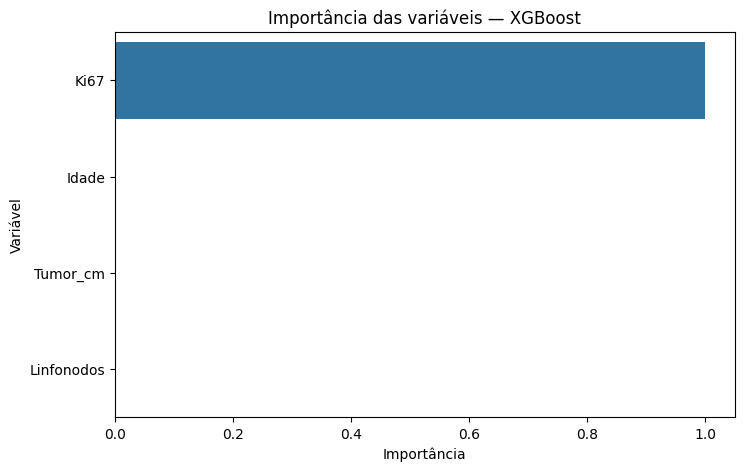

In [751]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    x=importancias.values,
    y=importancias.index
)

plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Importância das variáveis — XGBoost")

plt.show()


In [752]:
print("Ki67 por classe:")

for classe in sorted(df_limpo['TN'].unique()):
    valores = df_limpo.loc[df_limpo['TN'] == classe, 'Ki67']

    print(f"\nTN = {classe}")
    print(f"Mínimo: {valores.min()}")
    print(f"Máximo: {valores.max()}")


Ki67 por classe:

TN = 0
Mínimo: 6
Máximo: 48

TN = 1
Mínimo: 55
Máximo: 90


In [753]:
print(
    df_limpo[
        ['Ki67', 'TN']
    ].sort_values('Ki67').to_string(index=False)
)


 Ki67  TN
    6   0
    7   0
    7   0
    8   0
    8   0
    8   0
    8   0
    8   0
    9   0
    9   0
    9   0
    9   0
    9   0
    9   0
    9   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   10   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   11   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0
   12   0


In [745]:
print("Real:")
print(y_teste.values)

print()

print("Previsão:")
print(previsao_xgbost)


Real:
[0 1 1 1 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 1 0 1 0 1 0 1 1 0 0 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1 0 1 0 0 1 0 0
 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 1 1 1 0 0 0 1 1 0 1 0
 0 0 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 0
 0 0 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 1 1 0 0 1 0 1 1 1 1
 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 1 1 0 0 1 0 0
 1 0 0 0 1 0 1 0 1 0 1 1 1 1 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 1 0 1
 1 0 1 1 0 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 1 0 1 1 0 0 1
 0 0 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1
 0 0 1 0 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1
 0 0 1 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0 1 1 0 1 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 0 1 1 0 0 1
 0 1 0 1 1 0 0 1 1 0 0 1 1 0 1 0 1 1 0 1 1 0 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0
 1 1 1 1 1 0 1 0 0 

### Matriz de Confusão

A matriz de confusão é uma ferramenta útil para visualizar o desempenho de um algoritmo de classificação. Ela mostra o número de previsões corretas e incorretas para cada classe, permitindo identificar onde o modelo está errando.

Matriz de confusão:
[[259   0]
 [  0 295]]


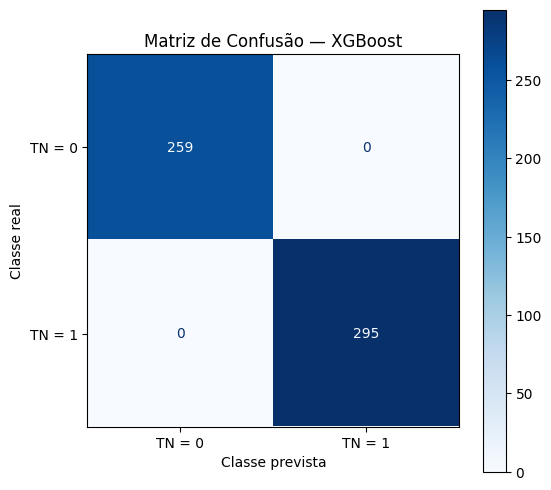

In [754]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fazer a previsão no conjunto de TESTE
previsao_teste = modelo_xgb.predict(X_teste)

# Calcular a matriz de confusão
cm = confusion_matrix(
    y_teste,
    previsao_teste,
    labels=[0, 1]
)

# Mostrar os valores da matriz
print("Matriz de confusão:")
print(cm)

# Nomes das classes
class_names = ['TN = 0', 'TN = 1']

# Criar a visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

# Plotar
fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(
    cmap=plt.cm.Blues,
    ax=ax,
    values_format='d'
)

plt.title('Matriz de Confusão — XGBoost')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')

plt.show()


In [756]:
"Qual variavel esta mais associada a TN"
print(
    df_limpo[
        ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67', 'TN']
    ].corr()
)


               Idade  Tumor_cm  Linfonodos      Ki67        TN
Idade       1.000000  0.013412    0.004215  0.006517  0.009226
Tumor_cm    0.013412  1.000000    0.945326  0.969349  0.923878
Linfonodos  0.004215  0.945326    1.000000  0.974698  0.924934
Ki67        0.006517  0.969349    0.974698  1.000000  0.963917
TN          0.009226  0.923878    0.924934  0.963917  1.000000


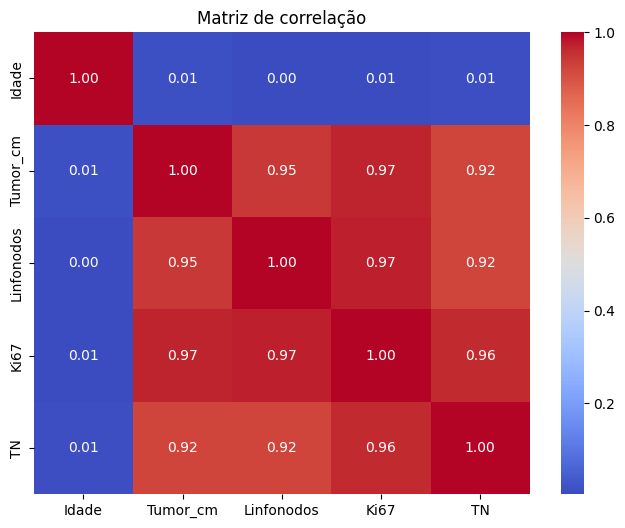

In [755]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_limpo[
        ['Idade', 'Tumor_cm', 'Linfonodos', 'Ki67', 'TN']
    ].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlação')
plt.show()
